## <font face = 'Times New Roma' size = 6> Spaceship Titanic

## <font face = 'Times New Roma' size = 5>1. Define The Problem

<font face = 'Times New Roma' size = 4>Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

<font face = 'Times New Roma' size = 4>The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

<font face = 'Times New Roma' size = 4>While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

<font face = 'Times New Roma' size = 4>To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

## <font face = 'Times New Roma' size = 5>2. Prepare Data for Consumption

### <font face = 'Times New Roma' size = 5>2.1. Import Fundamental Libraries

In [1]:
import pandas as pd
import matplotlib as mlt
import numpy as np
import sklearn
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

%matplotlib inline
mpl.style.use('ggplot')
plt.rcParams["font.family"]="Times New Roman"
sns.set_style('white')

### <font face = 'Times New Roma' size = 5>2.2. Load Data Modelling Libraries

In [2]:
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection, model_selection, metrics
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### <font face = 'Times New Roma' size = 5>2.3. Meet and Greet Data

In [3]:
data_raw = pd.read_csv('./train.csv')
data_val = pd.read_csv('./test.csv')

data1 = data_raw.copy(deep = True)
data_cleaner = [data1, data_val]

print(data_raw.info())
data_raw.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


## <font face = 'Times New Roma' size = 5>3. Data Cleaning

### <font face = 'Times New Roma' size = 5>3.1. Correcting And Completing

In [4]:
print(data1.isnull().sum(), data1.shape)
print('\n')
print(data_val.isnull().sum(), data_val.shape)

data_raw.describe()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64 (8693, 14)


PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64 (4277, 13)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
cate_columns = ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
bill_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
code_columns = ['CryoSleep', 'VIP']

label = LabelEncoder()

data1['Transported'] = label.fit_transform(data1['Transported'])

for dataset in data_cleaner:
    
    dataset['Age'] = dataset['Age'].fillna(value=dataset['Age'].mean())
    
    for cate_col in cate_columns:
        dataset[cate_col] = dataset[cate_col].fillna(method='ffill')
                                                     
    for bill_col in bill_columns:
        dataset[bill_col] = np.where(dataset['CryoSleep'] == 'True', 0, dataset[bill_col])
        dataset[bill_col] = np.where(dataset['Age'] < 14, 0, dataset[bill_col])
        dataset[bill_col] = dataset[bill_col].fillna(value=dataset[bill_col].mean())
    
    for code_col in code_columns:
        dataset[code_col] = label.fit_transform(dataset[code_col])

print(data1[cate_columns].nunique(), '\n')
print(data1.isnull().sum())
data1.head(10)

HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
dtype: int64 

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.000000,Maham Ofracculy,0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.000000,Juanna Vines,1
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.000000,Altark Susent,0
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.000000,Solam Susent,0
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.000000,Willy Santantines,1
5,0005_01,Earth,0,F/0/P,PSO J318.5-22,44.0,0,0.0,483.0,0.0,291.0,0.000000,Sandie Hinetthews,1
6,0006_01,Earth,0,F/2/S,TRAPPIST-1e,26.0,0,42.0,1539.0,3.0,0.0,0.000000,Billex Jacostaffey,1
7,0006_02,Earth,1,G/0/S,TRAPPIST-1e,28.0,0,0.0,0.0,0.0,0.0,300.596131,Candra Jacostaffey,1
8,0007_01,Earth,0,F/3/S,TRAPPIST-1e,35.0,0,0.0,785.0,17.0,216.0,0.000000,Andona Beston,1
9,0008_01,Europa,1,B/1/P,55 Cancri e,14.0,0,0.0,0.0,0.0,0.0,0.000000,Erraiam Flatic,1


### <font face = 'Times New Roma' size = 5>3.2. Creating And Converting

In [6]:
for dataset in data_cleaner:

    dataset['Group'] = dataset['PassengerId'].str.split('_', expand=True)[0]
    
    dataset['AgeBin'] = pd.cut(dataset['Age'], bins=(-1, 0, 16, 32, 56, 80))
    dataset['AgeBin'] = label.fit_transform(dataset['AgeBin'])
    
    dataset['CabinDeck'] = dataset['Cabin'].str.split('/', expand=True)[0]
    dataset['CabinNum'] = dataset['Cabin'].str.split('/', expand=True)[1].astype('int64')
    dataset['CabinSide'] = dataset['Cabin'].str.split('/', expand=True)[2]
    
    dataset['TotalBill'] = (dataset['RoomService'] + dataset['FoodCourt'] + dataset['ShoppingMall'] 
                            + dataset['Spa'] + dataset['VRDeck'])
    dataset['TotalBillBin'] = pd.cut(dataset['TotalBill'], bins=(-1, 0, 720, 1440, 36000))
    dataset['TotalBillBin'] = label.fit_transform(dataset['TotalBillBin'])
    
    dataset['FirstName'] = dataset['Name'].str.split(' ', expand=True)[0]
    dataset['LastName'] = dataset['Name'].str.split(' ', expand=True)[1]

In [7]:
norm_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalBill']

for dataset in data_cleaner:
    for norm_col in norm_columns:
        dataset[norm_col] = np.where((dataset[norm_col] > dataset[norm_col].mean() + dataset[norm_col].std() * 3),
                                      dataset[norm_col].mean() + dataset[norm_col].std() * 3,
                                      dataset[norm_col])
        dataset[norm_col] = dataset[norm_col]/dataset[norm_col].std()

In [8]:
Group = data1.groupby('Group')['PassengerId'].count().reset_index()
Group = Group.rename(columns = {'PassengerId': 'GroupSize'})
data1 = data1.merge(Group, how='left', on=['Group'])
    
Family = data1.groupby('LastName')['Name'].count().reset_index()
Family = Family.rename(columns = {'Name': 'FamilySize'})
data1 = data1.merge(Family, how='left', on=['LastName'])
    
dummy_columns = ['HomePlanet', 'CabinDeck', 'CabinSide', 'Destination']
Dummy = pd.get_dummies(data1[dummy_columns])
data1 = pd.concat([data1, Dummy], axis=1)

In [9]:
Group = data_val.groupby('Group')['PassengerId'].count().reset_index()
Group = Group.rename(columns = {'PassengerId': 'GroupSize'})
data_val = data_val.merge(Group, how='left', on=['Group'])
    
Family = data_val.groupby('LastName')['Name'].count().reset_index()
Family = Family.rename(columns = {'Name': 'FamilySize'})
data_val = data_val.merge(Family, how='left', on=['LastName'])
    
dummy_columns = ['HomePlanet', 'CabinDeck', 'CabinSide', 'Destination']
Dummy = pd.get_dummies(data_val[dummy_columns])
data_val = pd.concat([data_val, Dummy], axis=1)

In [10]:
x = [
    'CryoSleep', 
    'Age', 
    'VIP', 
    'CabinNum', 
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
    'TotalBill', 
    'GroupSize', 
    'FamilySize', 
    'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 
    'CabinDeck_A', 'CabinDeck_B', 'CabinDeck_C', 'CabinDeck_D', 'CabinDeck_E', 'CabinDeck_F', 'CabinDeck_G', 'CabinDeck_T', 
    'CabinSide_P', 'CabinSide_S', 
    'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e'
]
y = ['Transported']

### <font face = 'Times New Roma' size = 5>3.3. Split Training and Testing Data

In [11]:
train_x, test_x, train_y, test_y = model_selection.train_test_split(data1[x], data1[y], random_state = 0)

## <font face = 'Times New Roma' size = 5>4. Perform Exploratory Analysis with Statistics

In [12]:
data1_cate = ['HomePlanet', 'CryoSleep', 'AgeBin', 'Destination', 'CabinDeck', 'CabinSide', 'VIP', 
              'GroupSize', 'FamilySize', 'TotalBillBin']
data1_num = ['Age', 'CabinNum', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalBill']

for cate in data1_cate:
    print(data1[[cate, 'Transported']].groupby(cate, as_index=False).mean())
    print('-'*40, '\n')

  HomePlanet  Transported
0      Earth     0.424576
1     Europa     0.659164
2       Mars     0.522829
---------------------------------------- 

   CryoSleep  Transported
0          0     0.333393
1          1     0.809065
---------------------------------------- 

   AgeBin  Transported
0       0     0.808989
1       1     0.612076
2       2     0.471369
3       3     0.485921
4       4     0.502618
---------------------------------------- 

     Destination  Transported
0    55 Cancri e     0.609239
1  PSO J318.5-22     0.502451
2    TRAPPIST-1e     0.471592
---------------------------------------- 

  CabinDeck  Transported
0         A     0.500000
1         B     0.729763
2         C     0.676702
3         D     0.432990
4         E     0.361204
5         F     0.439059
6         G     0.516756
7         T     0.200000
---------------------------------------- 

  CabinSide  Transported
0         P     0.451703
1         S     0.554845
---------------------------------------- 

  

<AxesSubplot:xlabel='TotalBillBin', ylabel='Transported'>

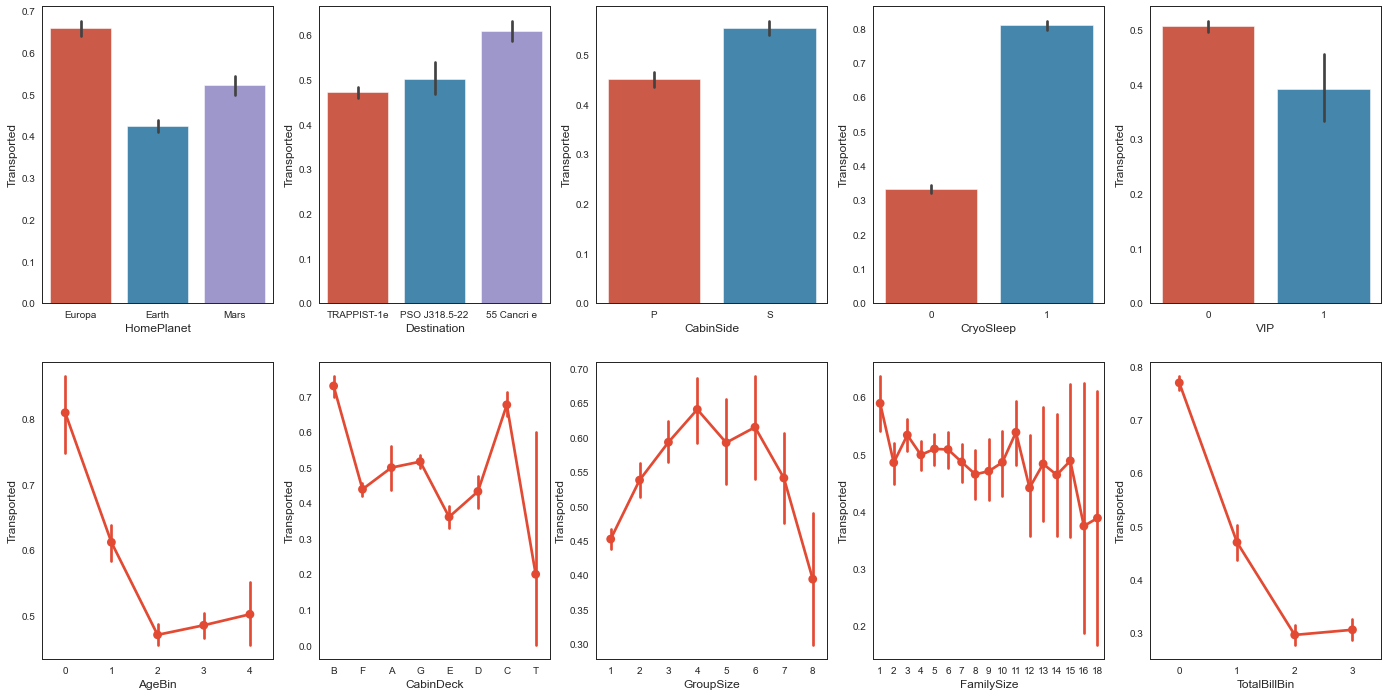

In [13]:
fig, ax = plt.subplots(2, 5,figsize=(24,12))

sns.barplot(x = 'HomePlanet', y = 'Transported', data=data1, ax=ax[0,0])
sns.barplot(x = 'Destination', y = 'Transported', data=data1, ax=ax[0,1])
sns.barplot(x = 'CabinSide', y = 'Transported', data=data1, ax=ax[0,2])
sns.barplot(x = 'CryoSleep', y = 'Transported', data=data1, ax=ax[0,3])
sns.barplot(x = 'VIP', y = 'Transported', data=data1, ax=ax[0,4])

sns.pointplot(x = 'AgeBin', y = 'Transported',  data=data1, ax=ax[1,0])
sns.pointplot(x = 'CabinDeck', y = 'Transported',  data=data1, ax=ax[1,1])
sns.pointplot(x = 'GroupSize', y = 'Transported', data=data1, ax=ax[1,2])
sns.pointplot(x = 'FamilySize', y = 'Transported', data=data1, ax=ax[1,3])
sns.pointplot(x = 'TotalBillBin', y = 'Transported', data=data1, ax=ax[1,4])

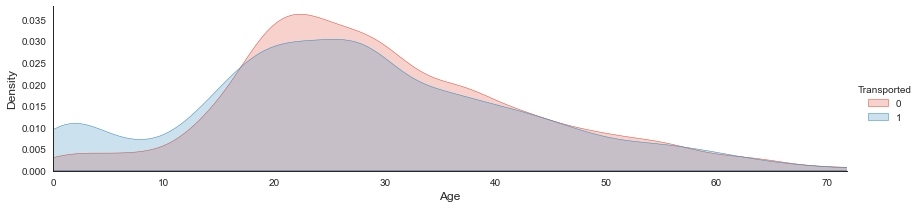

In [14]:
a = sns.FacetGrid(data1, hue='Transported', aspect=4)
a.map(sns.kdeplot, 'Age', shade= True )
a.set(xlim=(0 , data1['Age'].mean() + data1['Age'].std() * 3))
a.add_legend()

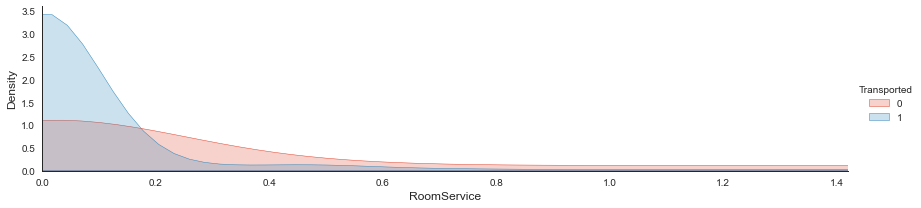

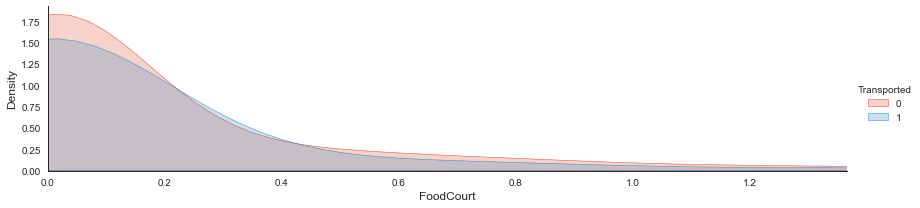

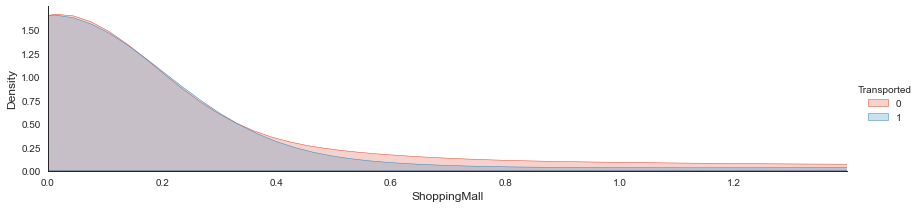

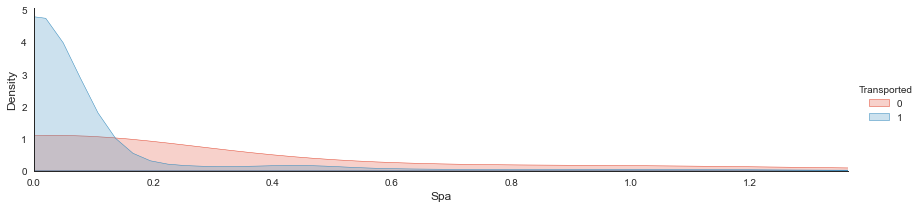

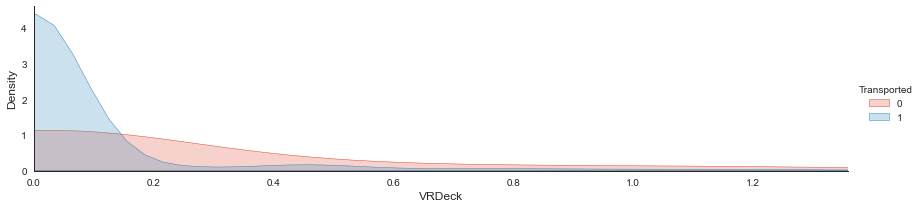

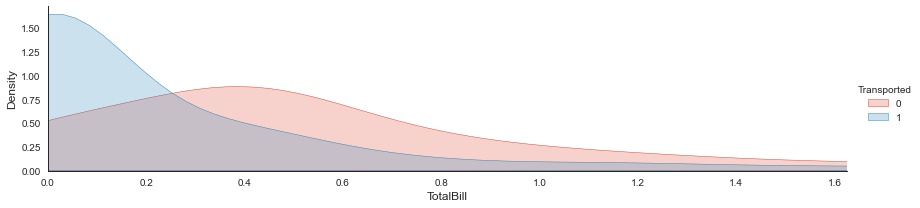

In [15]:
facet_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalBill']

for facet_col in facet_cols:
    a = sns.FacetGrid(data1, hue='Transported', aspect=4)
    a.map(sns.kdeplot, facet_col, shade= True )
    a.set(xlim=(0 , data1[facet_col].mean() + data1[facet_col].std()))
    a.add_legend()

In [16]:
drop_columns = ['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name', 'Group', 'CabinDeck', 
                'CabinSide', 'FirstName', 'LastName']

data1.drop(columns=drop_columns, inplace=True)
data_val.drop(columns=drop_columns, inplace=True)

## <font face = 'Times New Roma' size = 5>5. Model Data

In [17]:
MLA = [
    #Ensemble Methods
    ensemble.AdaBoostClassifier(),
    ensemble.BaggingClassifier(),
    ensemble.ExtraTreesClassifier(),
    ensemble.GradientBoostingClassifier(),
    ensemble.RandomForestClassifier(),

    #Gaussian Processes
#     gaussian_process.GaussianProcessClassifier(),
    
    #GLM
#     linear_model.LogisticRegressionCV(),
#     linear_model.PassiveAggressiveClassifier(),
    linear_model.RidgeClassifierCV(),
#     linear_model.SGDClassifier(),
#     linear_model.Perceptron(),
    
    #Navies Bayes
#     naive_bayes.BernoulliNB(),
    naive_bayes.GaussianNB(),
    
    #Nearest Neighbor
#     neighbors.KNeighborsClassifier(),
    
    #SVM
#     svm.SVC(probability=True),
#     svm.NuSVC(probability=True),
#     svm.LinearSVC(),
    
    #Trees    
#     tree.DecisionTreeClassifier(),
#     tree.ExtraTreeClassifier(),
    
    #Discriminant Analysis
    discriminant_analysis.LinearDiscriminantAnalysis(),
#     discriminant_analysis.QuadraticDiscriminantAnalysis(),

    #xgboost
    XGBClassifier(eval_metric='error')
]

In [18]:
cv_split = model_selection.ShuffleSplit(n_splits=10, test_size=0.3, train_size=0.6, random_state=0)

MLA_columns = ['MLA Name', 'MLA Parameters','MLA Train Accuracy Mean', 'MLA Test Accuracy Mean', 'MLA Test Accuracy 3*STD' ,'MLA Time']
MLA_compare = pd.DataFrame(columns=MLA_columns)

MLA_predict = data_val[['Age', 'CryoSleep']]

row_index = 0
for alg in MLA:

    MLA_name = alg.__class__.__name__
    MLA_compare.loc[row_index, 'MLA Name'] = MLA_name
    MLA_compare.loc[row_index, 'MLA Parameters'] = str(alg.get_params())
    
    cv_results = model_selection.cross_validate(alg, data1[x], data1[y], cv=cv_split, return_train_score=True)

    MLA_compare.loc[row_index, 'MLA Time'] = cv_results['fit_time'].mean()
    MLA_compare.loc[row_index, 'MLA Train Accuracy Mean'] = cv_results['train_score'].mean()
    MLA_compare.loc[row_index, 'MLA Test Accuracy Mean'] = cv_results['test_score'].mean() 
    MLA_compare.loc[row_index, 'MLA Test Accuracy 3*STD'] = cv_results['test_score'].std() * 3
    
    alg.fit(data1[x], data1[y])
    MLA_predict[MLA_name] = alg.predict(data_val[x])
    
    row_index += 1

MLA_predict.drop(columns=['Age', 'CryoSleep'], inplace=True)
MLA_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending=False, inplace=True)
MLA_compare

,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Test Accuracy Mean,MLA Test Accuracy 3*STD,MLA Time
3,GradientBoostingClassifier,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",0.830777,0.801879,0.027391,0.85411
8,XGBClassifier,"{'objective': 'binary:logistic', 'use_label_en...",0.965407,0.798926,0.025454,0.713448
4,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.999827,0.796779,0.034278,0.64287
2,ExtraTreesClassifier,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.999827,0.790529,0.030759,0.543226
0,AdaBoostClassifier,"{'algorithm': 'SAMME.R', 'base_estimator': Non...",0.797296,0.782209,0.022174,0.284436
5,RidgeClassifierCV,"{'alphas': array([ 0.1, 1. , 10. ]), 'class_w...",0.784084,0.780675,0.020109,0.026848
1,BaggingClassifier,"{'base_estimator': None, 'bootstrap': True, 'b...",0.985101,0.78056,0.022031,0.222358
7,LinearDiscriminantAnalysis,"{'covariance_estimator': None, 'n_components':...",0.78372,0.780521,0.020585,0.031585
6,GaussianNB,"{'priors': None, 'var_smoothing': 1e-09}",0.750585,0.75,0.035057,0.008386


## <font face = 'Times New Roma' size = 5>6. Submission

In [19]:
gbc = ensemble.GradientBoostingClassifier()
gbc.fit(data1[x], data1[y])
pre = gbc.predict(data_val[x])
print(pre[:5])
ans = pd.read_csv('./sample_submission.csv')
ans.Transported = pre
ans.Transported = ans.Transported == 1
ans.to_csv('Submission_gbc.csv', index=False)
ans.head()

[1 0 1 1 1]


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [20]:
rfc = ensemble.RandomForestClassifier()
rfc.fit(data1[x], data1[y])
pre = rfc.predict(data_val[x])
print(pre[:5])
ans = pd.read_csv('./sample_submission.csv')
ans.Transported = pre
ans.Transported = ans.Transported == 1
ans.to_csv('Submission_rfc.csv', index=False)
ans.head()

[0 0 1 1 1]


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [21]:
xgb = XGBClassifier(eval_metric='error')
xgb.fit(data1[x], data1[y])
pre = xgb.predict(data_val[x])
print(pre[:5])
ans = pd.read_csv('./sample_submission.csv')
ans.Transported = pre
ans.Transported = ans.Transported == 1
ans.to_csv('Submission_xgb.csv', index=False)
ans.head()

[1 0 1 1 1]


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [22]:
ans['Transported'] = gbc.predict(data_val[x]) + rfc.predict(data_val[x]) + xgb.predict(data_val[x])
ans['Transported'] = ans['Transported'] >= 2
ans.to_csv('Submission.csv', index=False)
ans.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
